# Spring–Slider with Pre-stress Offsets

This tutorial demonstrates the **normal offset** (`get_s0`) and
**tangential offset** (`get_w0`) parameters of `MuScaledSOCProjection`.
These translate the friction cone, modelling pre-loaded contacts,
cohesion, and tangential bias.

We use the **impulse-level** formulation where the contact impulse
$p = (p_N, p_T)$ is part of the augmented state and is projected
onto the friction cone $K_\mu$ at every step.
**Adaptive time-stepping** is used throughout.

### Physical setup

```
       k_T               μ
  ─/\/\/──┤ block ├──────┤ floor
   spring   mass    friction
```

A block of mass $m$ sits on a frictional floor ($\mu$).  A horizontal
spring with stiffness $k_T$ pulls it toward equilibrium $q_{\text{eq}}$.
When the spring force exceeds the static friction limit $\mu m g$,
the block slides partway and then sticks.

### What `get_s0` and `get_w0` do

The projection $\Pi_{K_\mu}(z)$ enforces $z \in K_\mu$.
With pre-stress offsets:

$$\Pi_{\text{ps}}(z) = \Pi_{K_\mu}(z + z_0) - z_0,
  \qquad z_0 = (s_0, w_0)$$

At the impulse level, the projected quantity $z = (p_N, p_T)$ is
the contact impulse per step.  The shifted friction law becomes:

$$|p_T + w_0| \le \mu\,(p_N + s_0)$$

- **`s0 > 0`**: boosts the effective normal impulse →
  friction capacity $\mu(p_N + s_0)$ exceeds the bare $\mu p_N$.
  Physically: **extra normal pre-load → more friction → harder to slide.**
- **`w0 ≠ 0`**: biases friction asymmetrically.

Since $p_N \propto h$ (impulse = force × time-step), `s0` must also
scale with $h$ to represent a constant physical force.  We define:

$$s_0 = F_{\text{extra}} \cdot h$$

and present results in terms of the equivalent extra force
$F_{\text{extra}}$ [N].

### Gravity via the cone offset

In this tutorial, **gravity is not included in the RHS**.  Instead,
the gravitational normal load is carried entirely by `s0`:

$$s_0^{\text{grav}} = m\,g\,h$$

This keeps the dynamical system free of body forces — the contact
projection alone determines the friction capacity.  Without gravity
in the RHS, the normal dynamics are trivially satisfied ($v_y = 0$,
$q_y = 0$), and the friction limit becomes $\mu\,s_0 / h = \mu\,m\,g$.

**Motivation (FEM dynamic instability):**  in FEM-scale simulations,
contacts often carry a pre-stress from loading history (bolt loads,
initial compression).  Computing a static equilibrium and using it
as an initial condition produces a **non-uniform** stress field that
is harder to solve.  Using `s0` instead **offsets the friction cone
directly** — the system starts from zero and the dynamics settle
naturally, with no static initialisation required.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from solve_nivp.contact import build_impulse_contact
import solve_nivp

## Part 1 — Baseline spring–slider (gravity via `s0`)

**Physical state:** $y = (v_x,\; v_y,\; q_x,\; q_y)$

| Idx | DOF    | Meaning                          |
|-----|--------|----------------------------------|
| 0   | $v_x$  | tangential velocity              |
| 1   | $v_y$  | normal velocity                  |
| 2   | $q_x$  | tangential position              |
| 3   | $q_y$  | normal position (gap)            |

`build_impulse_contact` automatically augments the state with
impulse DOFs $(p_N, p_T)$, constructs the coupling, De Saxcé
reaction rows, and the SOC projection.  We only provide the
smooth physics RHS (no contact, no gravity in the RHS).

Since `s0` must scale with the actual step size $h$, we pass
a mutable reference `_h` via `step_size_ref` — the auto-generated
RHS updates it on every call, and `get_s0` reads from it.
Adaptive time-stepping is enabled (`adaptive=True`).

In [4]:
# ── Physical parameters ──
mass  = 1.0
g     = 9.81
mu    = 0.5
k_T   = 5.0        # tangential spring stiffness [N/m]
q_eq  = 1.5         # spring equilibrium position [m]

# Friction limit vs spring force:
#   μ·m·g       = 4.905 N   (static friction, provided via s0)
#   k_T · q_eq  = 7.500 N   (max spring force at q_x = 0)
# The spring barely overcomes friction.

# Initial / nominal step size (adaptive stepping adjusts h)
h_fixed = 0.01      # [s]
t_span  = (0.0, 3.0)

# ── Mutable step-size reference ──
# Updated by the auto-generated rhs_aug via step_size_ref;
# read by get_s0 so the impulse offset scales with h.
_h = [h_fixed]

# ── Physical descriptor (4×4) ──
A_phys = np.diag([mass, mass, 1.0, 1.0])

def rhs_smooth(t, y):
    """Smooth physics RHS: spring force + kinematics.

    No gravity (carried by s0), no contact coupling (handled
    automatically by build_impulse_contact).
    """
    v_x, v_y = y[0], y[1]
    q_x = y[2]
    return np.array([
        -k_T * (q_x - q_eq),   # tangential spring force
        0.0,                     # normal: gravity via s0
        v_x,                     # kinematics
        v_y,
    ])
# Slip-weakening friction: μ decreases with tangential displacement
mu_s = 0.5    # static friction coefficient
mu_d = 0.3    # dynamic friction coefficient
D_c  = 0.5    # critical slip distance [m]

def mu_slip_weakening(y_phys):
    """Friction coefficient that weakens with tangential displacement."""
    q_x = y_phys[2]
    slip = abs(q_x)
    if slip < D_c:
        return mu_s - (mu_s - mu_d) * slip / D_c
    return mu_d
# Gap function: always-active contact.  Since gravity is carried by
# s0 (not the RHS), there is no restoring force in the normal
# direction — we tell the projector the contact is permanently
# closed so zero_inactive never deactivates it.
gap_func = lambda y, t: np.array([-1.0])

# ── Physical initial condition (4 DOFs) ──
y0_phys = np.zeros(4)

# ── Build augmented system ──
# Gravity via s0: s0 = m·g·h (current adaptive step size).
cs = build_impulse_contact(
    A=A_phys,
    rhs_smooth=rhs_smooth,
    y0=y0_phys,
    contacts=[dict(vel_normal_idx=1, vel_tangential_idx=[0], mu=mu_slip_weakening)],
    gap_func=gap_func,
    component_slices=[slice(0, 2), slice(2, 4)],
    get_s0=lambda y: mass * g * _h[0],
    step_size_ref=_h,
)

# ── Solve with flat API ──
t_base, y_base, h_hist, fk, info = solve_nivp.solve_ivp_ns(
    fun=cs.rhs,
    t_span=t_span,
    y0=cs.y0,
    A=cs.A,
    method='backward_euler',
    projection=cs.projection,
    solver='semismooth_newton',
    solver_opts=dict(tol=1e-12, max_iter=200),
    component_slices=cs.component_slices,
    integrator_opts=cs.integrator_opts,
    adaptive=True,
    h0=h_fixed,
)

n_phys = cs.n_phys   # = 4

print(f"Baseline: {len(t_base)} steps, final q_x = {y_base[-1, 2]:.4f}")
print(f"Max spring force = {k_T * q_eq:.1f} N")
print(f"Static friction  = {mu * mass * g:.2f} N  (via s0)")
print(f"Step sizes: min = {np.diff(t_base).min():.6f},  "
      f"max = {np.diff(t_base).max():.6f}")

Baseline: 98 steps, final q_x = 1.6688
Max spring force = 7.5 N
Static friction  = 4.91 N  (via s0)
Step sizes: min = 0.001585,  max = 0.510757


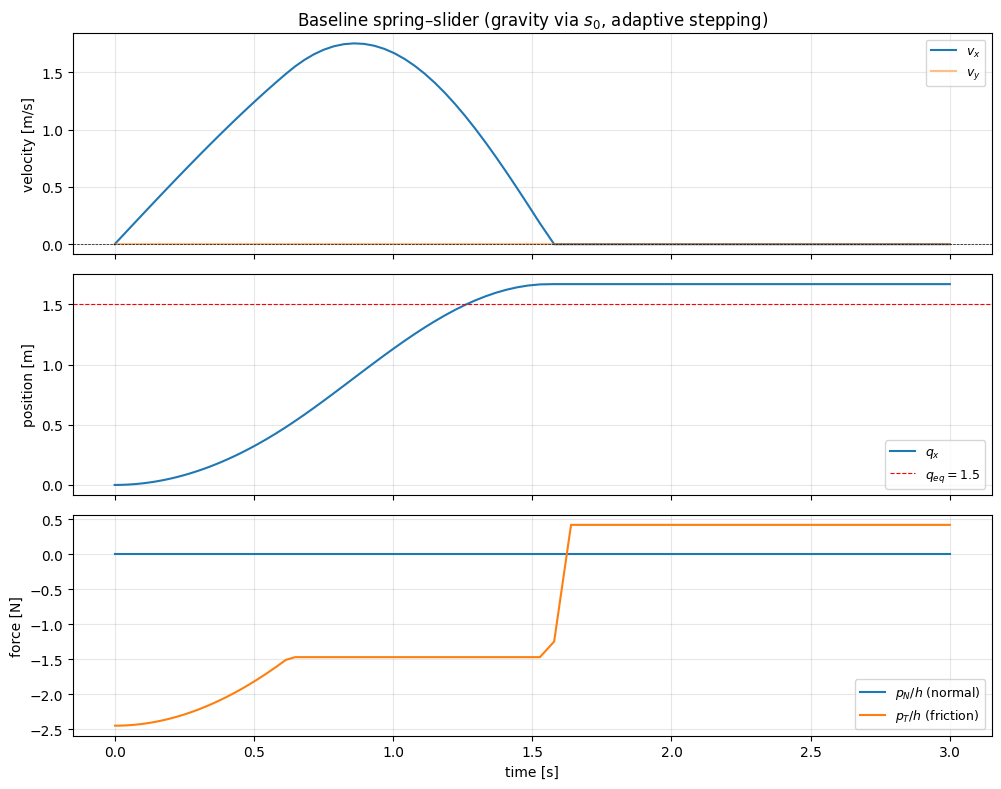

In [5]:
fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axs[0].plot(t_base, y_base[:, 0], label='$v_x$')
axs[0].plot(t_base, y_base[:, 1], label='$v_y$', alpha=0.5)
axs[0].axhline(0, color='k', lw=0.5, ls='--')
axs[0].set_ylabel('velocity [m/s]')
axs[0].legend(fontsize=9)
axs[0].set_title('Baseline spring–slider (gravity via $s_0$, adaptive stepping)')
axs[0].grid(True, alpha=0.3)

axs[1].plot(t_base, y_base[:, 2], label='$q_x$')
axs[1].axhline(q_eq, color='r', ls='--', lw=0.8, label=f'$q_{{eq}} = {q_eq}$')
axs[1].set_ylabel('position [m]')
axs[1].legend(fontsize=9)
axs[1].grid(True, alpha=0.3)

# Convert impulse to force — divide by actual adaptive step sizes.
h_steps = np.diff(t_base)
axs[2].plot(t_base[1:], y_base[1:, n_phys] / h_steps, label='$p_N / h$ (normal)')
axs[2].plot(t_base[1:], y_base[1:, n_phys + 1] / h_steps, label='$p_T / h$ (friction)')
axs[2].set_ylabel('force [N]')
axs[2].set_xlabel('time [s]')
axs[2].legend(fontsize=9)
axs[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 2 — Normal offset `get_s0`: extra pre-load on top of gravity

The baseline already uses $s_0 = m g h$ for gravity.  Adding an
extra normal force $F_{\text{extra}}$ on top:

$$s_0 = (m g + F_{\text{extra}}) \cdot h$$

The effective friction limit becomes
$\mu\,(p_N + s_0)/h = \mu\,(m g + F_{\text{extra}})$
(with $p_N \approx 0$ since gravity is carried by $s_0$).

| $F_{\text{extra}}$ [N] | Friction limit [N] | Spring force [N] | Outcome |
|:---:|:---:|:---:|:---:|
| 0 | 4.91 | 7.50 | slides freely |
| 2 | 5.91 | 7.50 | slides less |
| 4 | 6.91 | 7.50 | barely slides |
| 6 | 7.91 | 7.50 | **stuck** |

In [7]:
F_extra_values = [0.0, 2.0, 4.0, 6.0]
results_s0 = {}

for F_extra in F_extra_values:
    if F_extra == 0.0:
        results_s0[F_extra] = (t_base, y_base)
        continue

    # s0 = (m·g + F_extra) · h: gravity + extra normal pre-load.
    _F = F_extra
    cs_f = build_impulse_contact(
        A=A_phys,
        rhs_smooth=rhs_smooth,
        y0=y0_phys,
        contacts=[dict(vel_normal_idx=1, vel_tangential_idx=[0], mu=mu)],
        gap_func=gap_func,
        component_slices=[slice(0, 2), slice(2, 4)],
        get_s0=lambda y, _f=_F: (mass * g + _f) * _h[0],
        step_size_ref=_h,
    )
    t_, y_, _, _, _ = solve_nivp.solve_ivp_ns(
        fun=cs_f.rhs, t_span=t_span, y0=cs_f.y0, A=cs_f.A,
        method='backward_euler',
        projection=cs_f.projection,
        solver='semismooth_newton',
        solver_opts=dict(tol=1e-12, max_iter=200),
        component_slices=cs_f.component_slices,
        integrator_opts=cs_f.integrator_opts,
        adaptive=True, h0=h_fixed,
    )
    results_s0[F_extra] = (t_, y_)
    eff_friction = mu * (mass * g + F_extra)
    print(f"F_extra = {F_extra:.0f} N  →  friction limit = {eff_friction:.2f} N  |  "
          f"final q_x = {y_[-1, 2]:.4f}  |  steps = {len(t_)}")

print(f"\nBaseline (F_extra = 0): final q_x = {y_base[-1, 2]:.4f}")

F_extra = 2 N  →  friction limit = 5.91 N  |  final q_x = 0.6221  |  steps = 88
F_extra = 4 N  →  friction limit = 6.91 N  |  final q_x = 0.2320  |  steps = 79
F_extra = 6 N  →  friction limit = 7.91 N  |  final q_x = 0.0000  |  steps = 10

Baseline (F_extra = 0): final q_x = 1.0119


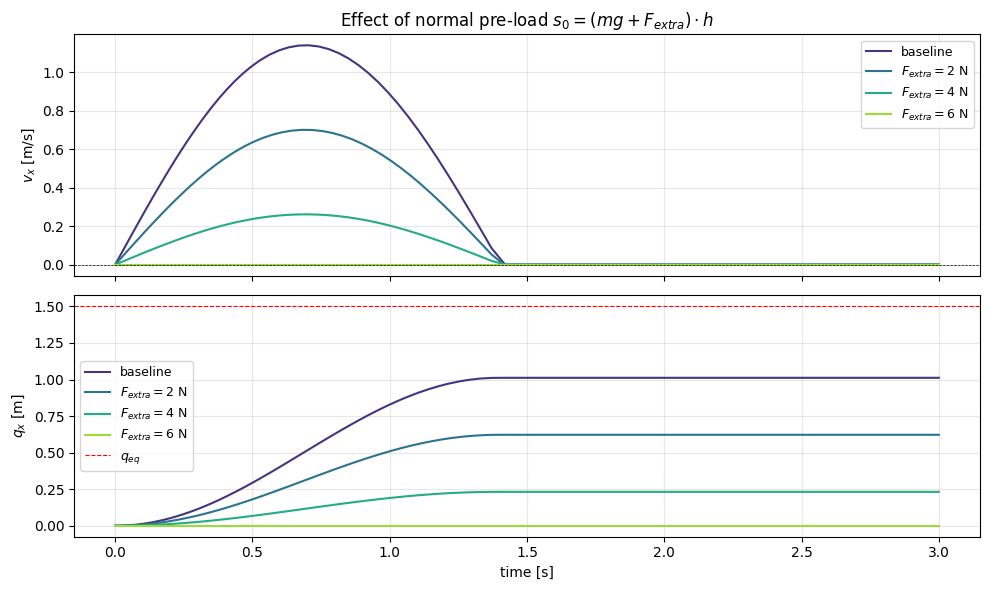

Higher F_extra → more friction → block slides less.
At F_extra ≥ 5.2 N, friction exceeds spring force → block is stuck.


In [8]:
fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(F_extra_values)))

for (F, (t_, y_)), c in zip(results_s0.items(), colors):
    lbl = 'baseline' if F == 0 else f'$F_{{extra}} = {F:.0f}$ N'
    axs[0].plot(t_, y_[:, 0], color=c, label=lbl)
    axs[1].plot(t_, y_[:, 2], color=c, label=lbl)

axs[0].axhline(0, color='k', lw=0.5, ls='--')
axs[0].set_ylabel('$v_x$ [m/s]')
axs[0].legend(fontsize=9)
axs[0].set_title('Effect of normal pre-load $s_0 = (mg + F_{extra}) \\cdot h$')
axs[0].grid(True, alpha=0.3)

axs[1].axhline(q_eq, color='r', ls='--', lw=0.8, label='$q_{eq}$')
axs[1].set_ylabel('$q_x$ [m]')
axs[1].set_xlabel('time [s]')
axs[1].legend(fontsize=9)
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Higher F_extra → more friction → block slides less.")
print(f"At F_extra ≥ {(k_T * q_eq / mu - mass * g):.1f} N, friction exceeds spring force → block is stuck.")


### Visualising the shifted cone

The projection $\Pi_{K_\mu}(z + z_0) - z_0$ is equivalent to
projecting onto a cone whose apex is at $(-s_0, 0)$ instead of
the origin.  The friction boundary widens.

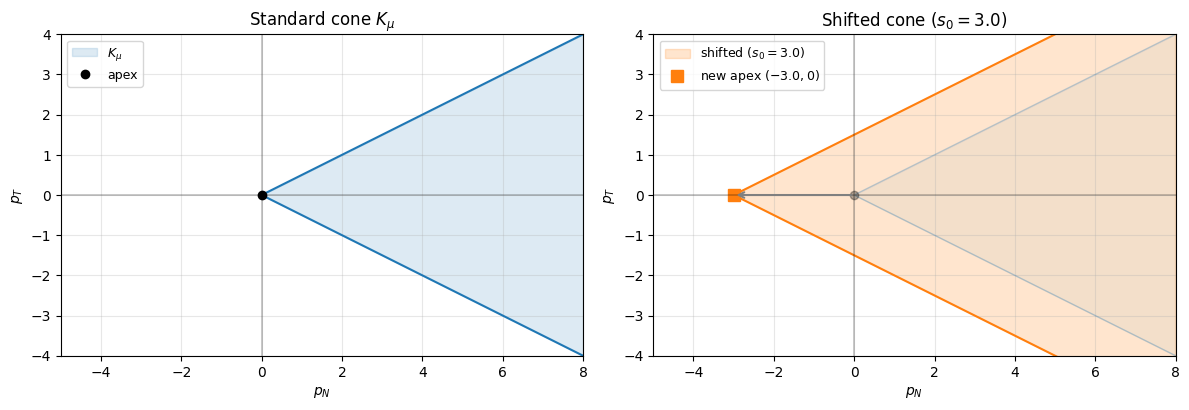

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

p_range = np.linspace(-6, 8, 300)

# Standard cone
ax = axs[0]
ok = p_range >= 0
ax.fill_between(p_range, -mu*p_range, mu*p_range, where=ok, alpha=0.15, color='C0',
                label='$K_\\mu$')
ax.plot(p_range[ok], mu*p_range[ok], 'C0-', lw=1.5)
ax.plot(p_range[ok], -mu*p_range[ok], 'C0-', lw=1.5)
ax.plot(0, 0, 'ko', ms=6, label='apex')
ax.set(xlabel='$p_N$', ylabel='$p_T$', title='Standard cone $K_\\mu$',
       xlim=(-5,8), ylim=(-4,4), aspect='equal')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
ax.axhline(0, color='k', lw=0.3); ax.axvline(0, color='k', lw=0.3)

# Shifted cone
s0_vis = 3.0
ax = axs[1]
ax.fill_between(p_range, -mu*p_range, mu*p_range, where=ok, alpha=0.06, color='C0')
ax.plot(p_range[ok], mu*p_range[ok], 'C0-', lw=1, alpha=0.3)
ax.plot(p_range[ok], -mu*p_range[ok], 'C0-', lw=1, alpha=0.3)
ok2 = (p_range + s0_vis) >= 0
ax.fill_between(p_range, -mu*(p_range+s0_vis), mu*(p_range+s0_vis), where=ok2,
                alpha=0.2, color='C1', label=f'shifted ($s_0={s0_vis}$)')
ax.plot(p_range[ok2], (mu*(p_range+s0_vis))[ok2], 'C1-', lw=1.5)
ax.plot(p_range[ok2], (-mu*(p_range+s0_vis))[ok2], 'C1-', lw=1.5)
ax.plot(0, 0, 'ko', ms=6, alpha=0.3)
ax.plot(-s0_vis, 0, 'C1s', ms=8, label=f'new apex $({-s0_vis}, 0)$')
ax.annotate('', xy=(-s0_vis, 0), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
ax.set(xlabel='$p_N$', ylabel='$p_T$', title=f'Shifted cone ($s_0={s0_vis}$)',
       xlim=(-5,8), ylim=(-4,4), aspect='equal')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
ax.axhline(0, color='k', lw=0.3); ax.axvline(0, color='k', lw=0.3)

plt.tight_layout()
plt.show()

## Part 3 — Tangential offset `get_w0`: friction bias

A tangential offset $w_0$ shifts the friction cone sideways:

$$|p_T + w_0| \le \mu\, (p_N + s_0)$$

This biases friction: easier to slide in the $-w_0$ direction,
harder in the $+w_0$ direction.

**Note:** since gravity is already in `s0`, the `w0`-only projectors
below also include the gravity offset $s_0 = m g h$.

**API:** `get_w0(y, k)` returns an array matching the tangential
DOF count of block $k$ (length 1 in 2D, length 2 in 3D).

In [10]:
F_bias_values = [0.0, 1.0, 2.0]
results_w0 = {}

for F_bias in F_bias_values:
    if F_bias == 0.0:
        results_w0[F_bias] = (t_base, y_base)
        continue

    _Fb = F_bias
    cs_w = build_impulse_contact(
        A=A_phys,
        rhs_smooth=rhs_smooth,
        y0=y0_phys,
        contacts=[dict(vel_normal_idx=1, vel_tangential_idx=[0], mu=mu)],
        gap_func=gap_func,
        component_slices=[slice(0, 2), slice(2, 4)],
        get_s0=lambda y: mass * g * _h[0],          # gravity via s0
        get_w0=lambda y, k, _f=_Fb: np.array([_f * _h[0]]),
        step_size_ref=_h,
    )
    t_, y_, _, _, _ = solve_nivp.solve_ivp_ns(
        fun=cs_w.rhs, t_span=t_span, y0=cs_w.y0, A=cs_w.A,
        method='backward_euler',
        projection=cs_w.projection,
        solver='semismooth_newton',
        solver_opts=dict(tol=1e-12, max_iter=200),
        component_slices=cs_w.component_slices,
        integrator_opts=cs_w.integrator_opts,
        adaptive=True, h0=h_fixed,
    )
    results_w0[F_bias] = (t_, y_)
    print(f"F_bias = {F_bias:.0f} N  →  final q_x = {y_[-1, 2]:.4f}  |  "
          f"steps = {len(t_)}")

print(f"\nBaseline: final q_x = {y_base[-1, 2]:.4f}")

F_bias = 1 N  →  final q_x = 0.6221  |  steps = 88
F_bias = 2 N  →  final q_x = 0.2320  |  steps = 79

Baseline: final q_x = 1.0119


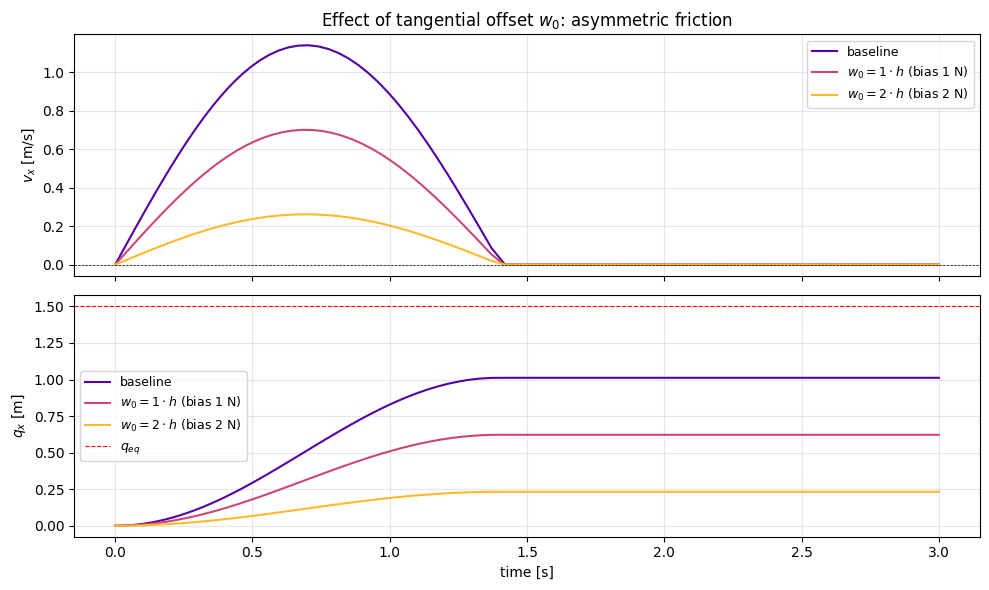

In [11]:
fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
colors = plt.cm.plasma(np.linspace(0.15, 0.85, len(F_bias_values)))

for (Fb, (t_, y_)), c in zip(results_w0.items(), colors):
    lbl = 'baseline' if Fb == 0 else f'$w_0 = {Fb:.0f} \\cdot h$ (bias {Fb:.0f} N)'
    axs[0].plot(t_, y_[:, 0], color=c, label=lbl)
    axs[1].plot(t_, y_[:, 2], color=c, label=lbl)

axs[0].axhline(0, color='k', lw=0.5, ls='--')
axs[0].set_ylabel('$v_x$ [m/s]')
axs[0].legend(fontsize=9)
axs[0].set_title('Effect of tangential offset $w_0$: asymmetric friction')
axs[0].grid(True, alpha=0.3)

axs[1].axhline(q_eq, color='r', ls='--', lw=0.8, label='$q_{eq}$')
axs[1].set_ylabel('$q_x$ [m]')
axs[1].set_xlabel('time [s]')
axs[1].legend(fontsize=9)
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 4 — Combined `s0 + w0`

Both offsets together:

$$|p_T + w_0| \le \mu\,(p_N + s_0)$$

Cone apex at $(-s_0, -w_0)$.

In [ ]:
F_ex_c = 3.0   # extra normal force [N]
F_bi_c = 1.0   # tangential bias [N]

cs_comb = build_impulse_contact(
    A=A_phys,
    rhs_smooth=rhs_smooth,
    y0=y0_phys,
    contacts=[dict(vel_normal_idx=1, vel_tangential_idx=[0], mu=mu)],
    gap_func=gap_func,
    component_slices=[slice(0, 2), slice(2, 4)],
    get_s0=lambda y: (mass * g + F_ex_c) * _h[0],   # gravity + extra
    get_w0=lambda y, k: np.array([F_bi_c * _h[0]]),
    step_size_ref=_h,
)
t_comb, y_comb, _, _, _ = solve_nivp.solve_ivp_ns(
    fun=cs_comb.rhs, t_span=t_span, y0=cs_comb.y0, A=cs_comb.A,
    method='backward_euler',
    projection=cs_comb.projection,
    solver='semismooth_newton',
    solver_opts=dict(tol=1e-12, max_iter=200),
    component_slices=cs_comb.component_slices,
    integrator_opts=cs_comb.integrator_opts,
    adaptive=True, h0=h_fixed,
)

print(f"Combined (F_extra={F_ex_c}, F_bias={F_bi_c}): "
      f"final q_x = {y_comb[-1, 2]:.4f}  |  steps = {len(t_comb)}")

Combined (F_extra=3.0, F_bias=1.0): final q_x = 0.0370  |  steps = 63


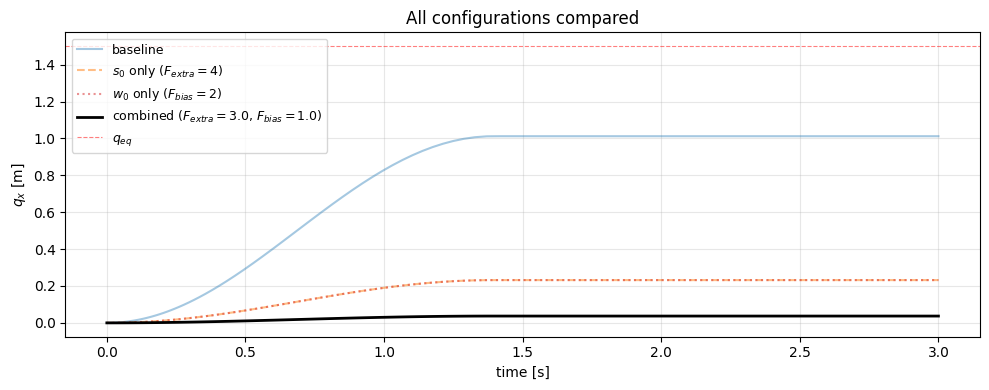

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(t_base, y_base[:, 2], 'C0-', alpha=0.4, label='baseline')
# Best s0-only and w0-only for reference
ax.plot(results_s0[4.0][0], results_s0[4.0][1][:, 2], 'C1--', alpha=0.5,
        label='$s_0$ only ($F_{extra}=4$)')
ax.plot(results_w0[2.0][0], results_w0[2.0][1][:, 2], 'C3:', alpha=0.5,
        label='$w_0$ only ($F_{bias}=2$)')
ax.plot(t_comb, y_comb[:, 2], 'k-', lw=2,
        label=f'combined ($F_{{extra}}={F_ex_c}$, $F_{{bias}}={F_bi_c}$)')
ax.axhline(q_eq, color='r', ls='--', lw=0.8, alpha=0.5, label='$q_{eq}$')
ax.set(xlabel='time [s]', ylabel='$q_x$ [m]', title='All configurations compared')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 5 — Cone geometry: combined shift

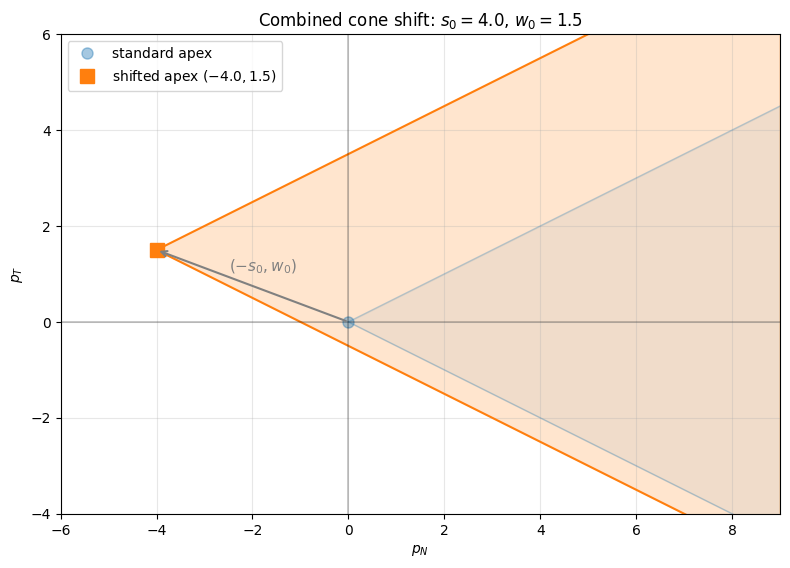

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))

p_range = np.linspace(-7, 9, 300)

# Standard cone (faded)
ok0 = p_range >= 0
ax.fill_between(p_range, -mu*p_range, mu*p_range, where=ok0, alpha=0.08, color='C0')
ax.plot(p_range[ok0], mu*p_range[ok0], 'C0-', lw=1, alpha=0.3)
ax.plot(p_range[ok0], -mu*p_range[ok0], 'C0-', lw=1, alpha=0.3)
ax.plot(0, 0, 'C0o', ms=8, alpha=0.4, label='standard apex')

# Shifted cone with s0 + w0
s0_v, w0_v = 4.0, 1.5
s_sh = p_range + s0_v
ok1 = s_sh >= 0
ax.fill_between(p_range, -mu*s_sh + w0_v, mu*s_sh + w0_v, where=ok1,
                alpha=0.2, color='C1')
ax.plot(p_range[ok1], (mu*s_sh + w0_v)[ok1], 'C1-', lw=1.5)
ax.plot(p_range[ok1], (-mu*s_sh + w0_v)[ok1], 'C1-', lw=1.5)
ax.plot(-s0_v, w0_v, 'C1s', ms=10,
        label=f'shifted apex $(-{s0_v}, {w0_v})$')
ax.annotate('', xy=(-s0_v, w0_v), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
ax.text(-s0_v/2 - 0.5, w0_v/2 + 0.3, '$(-s_0, w_0)$', fontsize=11, color='gray')

ax.set(xlabel='$p_N$', ylabel='$p_T$',
       title=f'Combined cone shift: $s_0={s0_v}$, $w_0={w0_v}$',
       xlim=(-6, 9), ylim=(-4, 6), aspect='equal')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.axhline(0, color='k', lw=0.3); ax.axvline(0, color='k', lw=0.3)

plt.tight_layout()
plt.show()

## Part 6 — State-dependent `s0` with Jacobian

When `s0` depends on the state, supply the Jacobian
`get_ds0_dz` for quadratic SSN convergence.

Example: contact pressure increases linearly with displacement —
$s_0(y) = (m g + k_{\text{ramp}} \max(0,\, q_x)) \cdot h$.  
As the block slides further, friction grows, slowing it down
more than the constant-$s_0$ case.

$$\frac{\partial s_0}{\partial y}
  = (0,\;0,\;k_{\text{ramp}} h,\;0,\;0,\;0) \quad \text{when } q_x > 0$$

In [15]:
k_ramp = 5.0   # ramp rate [N/m]: contact pressure increases with q_x

def get_s0_ramp(y):
    """State-dependent: gravity + ramping pre-load with displacement."""
    return (mass * g + k_ramp * max(0.0, y[2])) * _h[0]

def get_ds0_dz_ramp(y):
    """Jacobian of s0 w.r.t. full augmented state vector."""
    grad = np.zeros(6)   # augmented size: 4 phys + 2 reaction
    if y[2] > 0:
        grad[2] = k_ramp * _h[0]
    return grad

cs_sd = build_impulse_contact(
    A=A_phys,
    rhs_smooth=rhs_smooth,
    y0=y0_phys,
    contacts=[dict(vel_normal_idx=1, vel_tangential_idx=[0], mu=mu)],
    gap_func=gap_func,
    component_slices=[slice(0, 2), slice(2, 4)],
    get_s0=get_s0_ramp,
    get_ds0_dz=get_ds0_dz_ramp,
    step_size_ref=_h,
)
t_sd, y_sd, _, _, _ = solve_nivp.solve_ivp_ns(
    fun=cs_sd.rhs, t_span=t_span, y0=cs_sd.y0, A=cs_sd.A,
    method='backward_euler',
    projection=cs_sd.projection,
    solver='semismooth_newton',
    solver_opts=dict(tol=1e-12, max_iter=200),
    component_slices=cs_sd.component_slices,
    integrator_opts=cs_sd.integrator_opts,
    adaptive=True, h0=h_fixed,
)

print(f"State-dependent s0: {len(t_sd)} steps, final q_x = {y_sd[-1, 2]:.4f}")
print(f"Baseline:                            final q_x = {y_base[-1, 2]:.4f}")
print(f"\nPeak s0/h = {(mass*g + k_ramp * y_sd[:, 2].max()):.2f} N "
      f"(at q_x = {y_sd[:, 2].max():.4f})")
print(f"Friction limit at peak: μ·s0/h = {mu * (mass*g + k_ramp * y_sd[:, 2].max()):.2f} N")

State-dependent s0: 90 steps, final q_x = 0.6750
Baseline:                            final q_x = 1.0119

Peak s0/h = 13.19 N (at q_x = 0.6750)
Friction limit at peak: μ·s0/h = 6.59 N


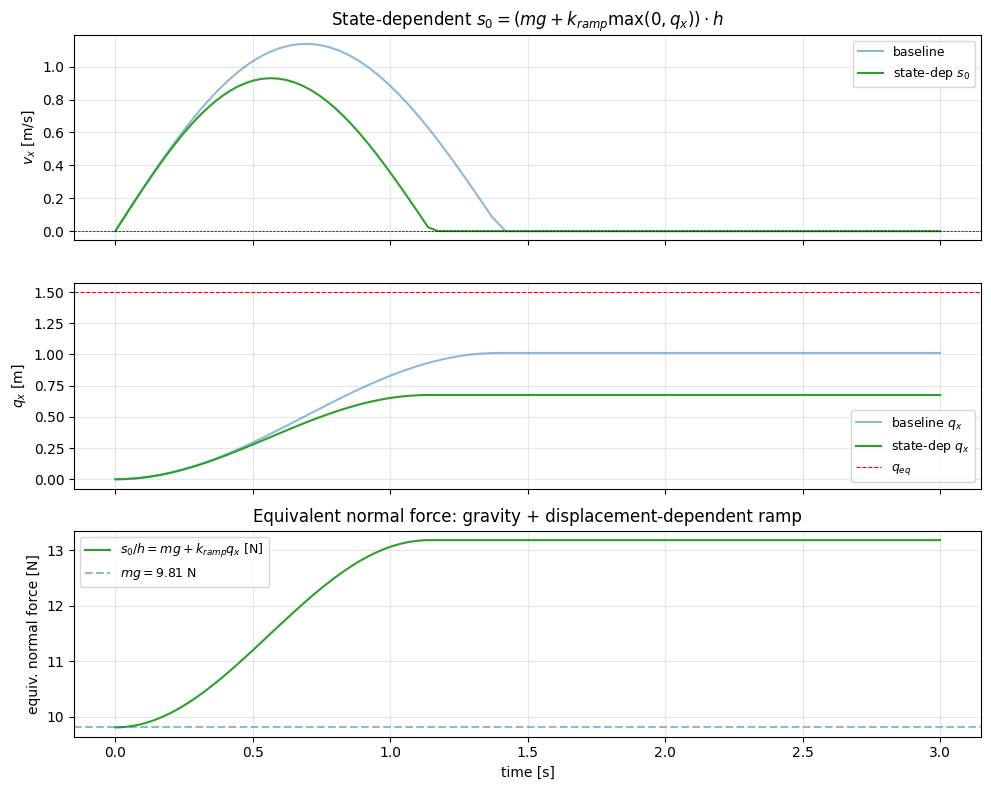

In [16]:
fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axs[0].plot(t_base, y_base[:, 0], 'C0-', alpha=0.5, label='baseline')
axs[0].plot(t_sd, y_sd[:, 0], 'C2-', label='state-dep $s_0$')
axs[0].axhline(0, color='k', lw=0.5, ls='--')
axs[0].set_ylabel('$v_x$ [m/s]')
axs[0].legend(fontsize=9)
axs[0].set_title('State-dependent $s_0 = (mg + k_{ramp} \\max(0, q_x)) \\cdot h$')
axs[0].grid(True, alpha=0.3)

axs[1].plot(t_base, y_base[:, 2], 'C0-', alpha=0.5, label='baseline $q_x$')
axs[1].plot(t_sd, y_sd[:, 2], 'C2-', label='state-dep $q_x$')
axs[1].axhline(q_eq, color='r', ls='--', lw=0.8, label='$q_{eq}$')
axs[1].set_ylabel('$q_x$ [m]')
axs[1].legend(fontsize=9)
axs[1].grid(True, alpha=0.3)

# Equivalent extra normal force from ramp
s0_equiv = np.array([(mass * g + k_ramp * max(0, y_sd[i, 2])) for i in range(len(t_sd))])
axs[2].plot(t_sd, s0_equiv, 'C2-', label='$s_0/h = mg + k_{ramp} q_x$ [N]')
axs[2].axhline(mass * g, color='C0', ls='--', alpha=0.5, label=f'$mg = {mass*g:.2f}$ N')
axs[2].set_ylabel('equiv. normal force [N]')
axs[2].set_xlabel('time [s]')
axs[2].legend(fontsize=9)
axs[2].set_title('Equivalent normal force: gravity + displacement-dependent ramp')
axs[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## API Summary

| Parameter | Signature | Effect |
|-----------|-----------|--------|
| `get_s0` | `(y)` or `(y, t)` or `(y, t, Fk_val)` → scalar | Normal pre-stress: shifted friction limit $\mu(p_N + s_0)$. |
| `get_w0` | `(y, k)` or `(y, k, t)` → array(m) | Tangential pre-stress: biases the cone sideways. |
| `get_ds0_dz` | `(y)` → array(n) | Jacobian $\partial s_0/\partial y$ for quadratic SSN. |
| `get_dw0_dz` | `(y, k)` → array(m, n) | Jacobian $\partial w_0/\partial y$ for tangential offset. |
| `step_size_ref` | mutable `[h]` list | Shared reference updated by auto-generated RHS; `get_s0` reads it. |

### Using `build_impulse_contact` with pre-stress

The flat API pattern demonstrated in this notebook:

```python
_h = [h_fixed]          # mutable step-size reference

cs = build_impulse_contact(
    A=A_phys, rhs_smooth=rhs_smooth, y0=y0_phys,
    contacts=[dict(vel_normal_idx=1, vel_tangential_idx=[0], mu=mu)],
    gap_func=gap_func,
    component_slices=[slice(0, 2), slice(2, 4)],
    get_s0=lambda y: mass * g * _h[0],   # gravity via cone offset
    step_size_ref=_h,                     # auto-updated by rhs_aug
)

t, y, *_ = solve_nivp.solve_ivp_ns(
    fun=cs.rhs, t_span=t_span, y0=cs.y0, A=cs.A,
    method='backward_euler',
    projection=cs.projection, solver='semismooth_newton',
    solver_opts=dict(tol=1e-12, max_iter=200),
    component_slices=cs.component_slices,
    integrator_opts=cs.integrator_opts,
    adaptive=True, h0=h_fixed,
)
```

### Implementation details

1. **Projection formula:**
   $\Pi_{\text{ps}}(z) = \Pi_{K_\mu}(z + z_0) - z_0$
   Shift `z_blk` by `+z_0`, project, shift back by `-z_0`.

2. **Tangent cone correction (state-dependent offsets):**
   $D_{\text{ps}} = J_\pi + (J_\pi - I) \cdot \partial z_0 / \partial y$
   Assembled by `_assemble_dz0_block` internally.

3. **Calling convention:**
   `get_s0` uses auto-arity (same as `get_mu`).
   `get_w0(y, k)` includes block index $k$ and returns an array
   matching the tangential dimension of that block.

4. **Impulse scaling & adaptive stepping:**
   At impulse level, $s_0 = F_{\text{extra}} \cdot h$ to represent
   a constant extra normal force.  The `step_size_ref` mechanism
   ensures `get_s0` always sees the current adaptive $h$.

5. **Gravity via `s0`:**
   Body forces like gravity can be moved entirely into the cone
   offset ($s_0 = m g h$), keeping the RHS free of body forces.
   This avoids static initialisation in FEM problems.

6. **`MoreauSOCProjection` compatibility:**
   Inherits `get_s0`/`get_w0`.  Pre-stress is applied between
   forward and inverse De Saxcé transforms.

In [ ]:
## Part 7 — Frictional instability via time-dependent `w0`

Choose a normal offset $F_{\text{extra}} = 10$ N large enough to
**lock the block**: the friction limit

$$\mu\,(mg + F_{\text{extra}}) = 0.5 \times 19.81 = 9.91 \;\text{N}$$

exceeds the spring force $k_T q_{\text{eq}} = 7.5$ N, so the block
cannot slide under spring loading alone.

Then prescribe a **time-ramping tangential offset** $w_0(t)$ that
linearly reduces the effective friction capacity in the sliding
direction.  The critical tangential force at which friction is
exactly balanced is:

$$F_{w,\text{crit}} = \mu\,(mg + F_{\text{extra}}) - k_T\, q_{\text{eq}}$$

The ramp $F_w(t) = F_{w,\text{crit}} \cdot \min(t, 1)$ reaches
the threshold at $t = 1$ s and **holds** at that value.
Before $t = 1$ the block is stuck; at $t = 1$
**frictional instability** begins — the block is right at the
sliding threshold with zero margin.

### Sign convention

The spring pulls in $+x$ (toward $q_{\text{eq}}$), so friction
opposes in $-x$: $p_T < 0$.  The shifted cone is

$$|p_T + w_0| \le \mu\,(p_N + s_0)$$

A **negative** $w_0$ adds to $|p_T|$, reducing the margin.
At the critical value, $|p_T + w_0|$ equals $\mu\, s_0$ and
sliding commences.

SyntaxError: invalid syntax (1839771352.py, line 3)

In [24]:
# ── Normal offset: large enough to lock the block ──
F_extra_inst = 10.0   # [N]
friction_limit = mu * (mass * g + F_extra_inst)
spring_force   = k_T * q_eq

print(f"Friction limit  = μ(mg + F_extra) = {friction_limit:.2f} N")
print(f"Spring force    = k_T · q_eq      = {spring_force:.1f} N")
print(f"Margin          = {friction_limit - spring_force:.3f} N  →  block is STUCK\n")

# ── Critical tangential force for frictional instability ──
F_w_crit = friction_limit - spring_force
print(f"F_w_crit = {F_w_crit:.3f} N")
print(f"Ramp reaches threshold at t = 1 s, then holds constant.\n")

# ── Time-dependent tangential offset (clamped at t = 1) ──
# w0(t) = -F_w(t) · h   (negative to reduce friction margin)
# F_w(t) = F_w_crit · min(t, 1)  (ramp to threshold, then plateau)
def get_w0_instab(y, k, t):
    F_w = F_w_crit * min(t, 1.001)
    return np.array([-F_w * _h[0]])

cs_inst = build_impulse_contact(
    A=A_phys,
    rhs_smooth=rhs_smooth,
    y0=y0_phys,
    contacts=[dict(vel_normal_idx=1, vel_tangential_idx=[0], mu=mu)],
    gap_func=gap_func,
    component_slices=[slice(0, 2), slice(2, 4)],
    get_s0=lambda y: (mass * g + F_extra_inst) * _h[0],
    get_w0=get_w0_instab,
    step_size_ref=_h,
)

t_inst, y_inst, _, _, _ = solve_nivp.solve_ivp_ns(
    fun=cs_inst.rhs,
    t_span=t_span,
    y0=cs_inst.y0,
    A=cs_inst.A,
    method='backward_euler',
    projection=cs_inst.projection,
    solver='semismooth_newton',
    solver_opts=dict(tol=1e-12, max_iter=200),
    component_slices=cs_inst.component_slices,
    integrator_opts=cs_inst.integrator_opts,
    adaptive=True,
    h0=h_fixed,
)

print(f"Instability run: {len(t_inst)} steps, final q_x = {y_inst[-1, 2]:.4f}")
print(f"v_x at t = 0.99: {np.interp(0.99, t_inst, y_inst[:, 0]):.6f}  (should be ≈ 0)")
print(f"v_x at t = 1.10: {np.interp(1.10, t_inst, y_inst[:, 0]):.6f}  (at threshold)")

Friction limit  = μ(mg + F_extra) = 9.91 N
Spring force    = k_T · q_eq      = 7.5 N
Margin          = 2.405 N  →  block is STUCK

F_w_crit = 2.405 N
Ramp reaches threshold at t = 1 s, then holds constant.

Instability run: 42 steps, final q_x = 0.0009
v_x at t = 0.99: 0.000000  (should be ≈ 0)
v_x at t = 1.10: 0.000250  (at threshold)


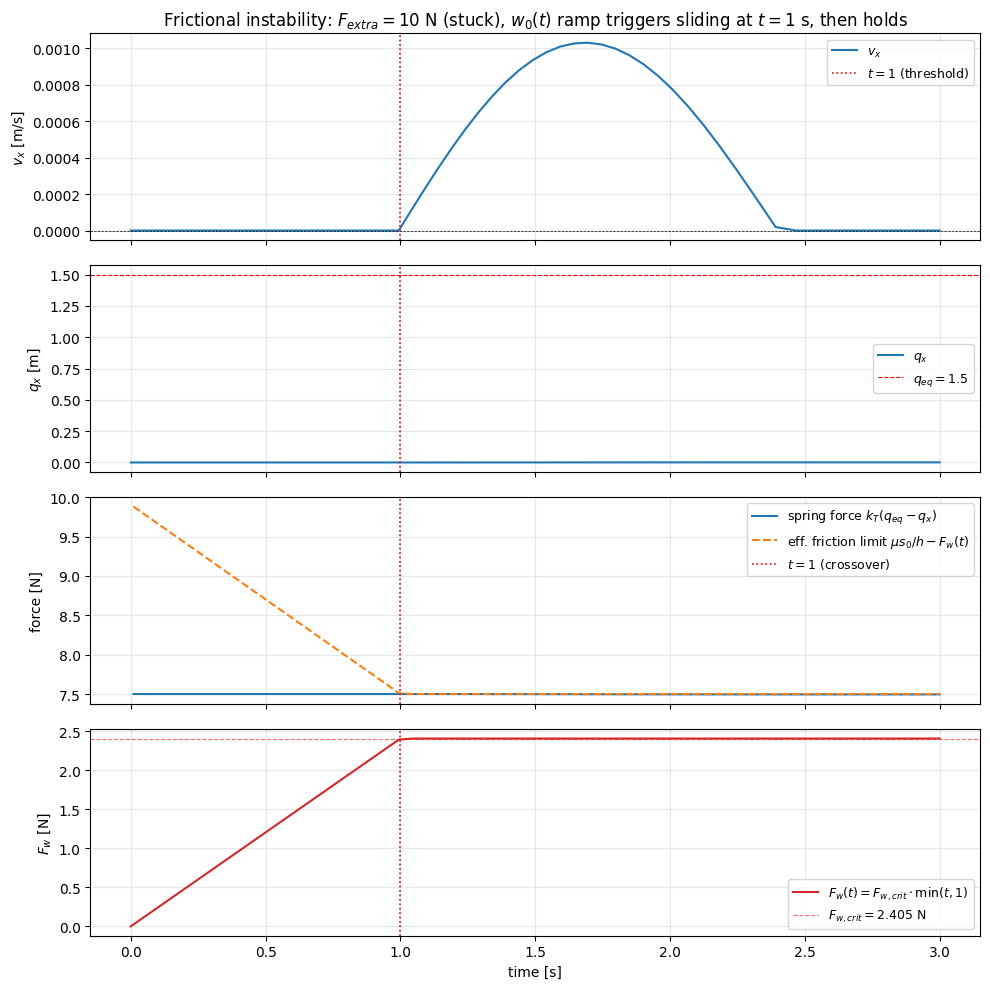


Block is stuck for t < 1 s  (friction limit 9.91 N > spring force 7.5 N)
At t = 1 s: w0 ramp removes 2.405 N margin → threshold reached
For t > 1 s: F_w held constant at 2.405 N
Final q_x = 0.0009 m


In [25]:
fig, axs = plt.subplots(4, 1, figsize=(10, 10), sharex=True)

# Velocity
axs[0].plot(t_inst, y_inst[:, 0], 'C0-', label='$v_x$')
axs[0].axhline(0, color='k', lw=0.5, ls='--')
axs[0].axvline(1.0, color='r', ls=':', lw=1.2, label='$t = 1$ (threshold)')
axs[0].set_ylabel('$v_x$ [m/s]')
axs[0].legend(fontsize=9)
axs[0].set_title(
    f'Frictional instability: $F_{{extra}} = {F_extra_inst:.0f}$ N '
    f'(stuck), $w_0(t)$ ramp triggers sliding at $t = 1$ s, then holds')
axs[0].grid(True, alpha=0.3)

# Position
axs[1].plot(t_inst, y_inst[:, 2], 'C0-', label='$q_x$')
axs[1].axhline(q_eq, color='r', ls='--', lw=0.8, label=f'$q_{{eq}} = {q_eq}$')
axs[1].axvline(1.0, color='r', ls=':', lw=1.2)
axs[1].set_ylabel('$q_x$ [m]')
axs[1].legend(fontsize=9)
axs[1].grid(True, alpha=0.3)

# Force balance: spring force vs effective friction limit
h_arr = np.diff(t_inst)
t_mid = t_inst[1:]
F_spring_arr = k_T * (q_eq - y_inst[1:, 2])
F_fric_eff = friction_limit - np.array([F_w_crit * min(t, 1.0) for t in t_mid])
axs[2].plot(t_mid, F_spring_arr, 'C0-', label='spring force $k_T(q_{eq} - q_x)$')
axs[2].plot(t_mid, F_fric_eff, 'C1--', label='eff. friction limit $\\mu s_0/h - F_w(t)$')
axs[2].axvline(1.0, color='r', ls=':', lw=1.2, label='$t = 1$ (crossover)')
axs[2].set_ylabel('force [N]')
axs[2].legend(fontsize=9)
axs[2].grid(True, alpha=0.3)

# Tangential offset ramp (clamped at t=1)
F_w_arr = np.array([F_w_crit * min(t, 1.0) for t in t_inst])
axs[3].plot(t_inst, F_w_arr, 'C3-', label='$F_w(t) = F_{w,crit} \\cdot \\min(t, 1)$')
axs[3].axhline(F_w_crit, color='r', ls='--', lw=0.8, alpha=0.6,
               label=f'$F_{{w,crit}} = {F_w_crit:.3f}$ N')
axs[3].axvline(1.0, color='r', ls=':', lw=1.2)
axs[3].set_ylabel('$F_w$ [N]')
axs[3].set_xlabel('time [s]')
axs[3].legend(fontsize=9)
axs[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nBlock is stuck for t < 1 s  (friction limit {friction_limit:.2f} N > "
      f"spring force {spring_force:.1f} N)")
print(f"At t = 1 s: w0 ramp removes {F_w_crit:.3f} N margin → threshold reached")
print(f"For t > 1 s: F_w held constant at {F_w_crit:.3f} N")
print(f"Final q_x = {y_inst[-1, 2]:.4f} m")